# CBIS-DDSM

## 1. Imports

In [1]:
import copy
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import time
import os
import gc
from sklearn.metrics import classification_report
from PIL import Image
import cv2
from torch.utils.data import random_split


## 2. Config & DataLoader

In [ ]:
DATA_DIR = "dataset"
BATCH_SIZE = 32
NUM_EPOCHS = 30 
LEARNING_RATE = 1e-4  
PATIENCE = 7        
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class CLAHETransform:
    """Apply CLAHE to improve mammogram contrast."""
    def __init__(self, clip_limit=2.0, tile_grid_size=(8, 8)):
        self.clip_limit = clip_limit
        self.tile_grid_size = tile_grid_size

    def __call__(self, img):
        img_np = np.array(img)
        if len(img_np.shape) == 2:
            clahe = cv2.createCLAHE(clipLimit=self.clip_limit, tileGridSize=self.tile_grid_size)
            img_np = clahe.apply(img_np)
        else:
            img_lab = cv2.cvtColor(img_np, cv2.COLOR_RGB2LAB)
            clahe = cv2.createCLAHE(clipLimit=self.clip_limit, tileGridSize=self.tile_grid_size)
            img_lab[:, :, 0] = clahe.apply(img_lab[:, :, 0])
            img_np = cv2.cvtColor(img_lab, cv2.COLOR_LAB2RGB)
        return Image.fromarray(img_np)

data_transforms = {
    'train': transforms.Compose([
        CLAHETransform(clip_limit=3.0),      
        transforms.Resize((256, 256)),         
        transforms.RandomCrop((224, 224)),     
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.5),
        transforms.RandomRotation(20),         
        transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
        transforms.ColorJitter(brightness=0.3, contrast=0.3),
        transforms.RandomAdjustSharpness(sharpness_factor=2, p=0.3),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        CLAHETransform(clip_limit=2.0),
        transforms.Resize((224, 224)), 
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

# Proper Train/Val/Test Split
full_train_dataset = datasets.ImageFolder(os.path.join(DATA_DIR, 'train'), data_transforms['train'])
val_size = int(0.2 * len(full_train_dataset))
train_size = len(full_train_dataset) - val_size
train_dataset, val_dataset = random_split(
    full_train_dataset, 
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

from torch.utils.data import Subset

class TransformSubset(torch.utils.data.Dataset):
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform
    def __getitem__(self, idx):
        img_path, label = self.subset.dataset.samples[self.subset.indices[idx]]
        img = Image.open(img_path).convert('RGB')
        return self.transform(img), label
    def __len__(self):
        return len(self.subset)

val_dataset = TransformSubset(val_dataset, data_transforms['test'])

test_dataset = datasets.ImageFolder(os.path.join(DATA_DIR, 'test'), data_transforms['test'])

from torch.utils.data import WeightedRandomSampler
from sklearn.utils.class_weight import compute_class_weight

train_labels = np.array([full_train_dataset.samples[i][1] for i in train_dataset.indices])
class_weights = compute_class_weight('balanced', classes=np.unique(train_labels), y=train_labels)
sample_weights = class_weights[train_labels]
weighted_sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(train_labels),
    replacement=True
)

dataloaders = {
    'train': DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=weighted_sampler, num_workers=0),
    'val': DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0),
    'test': DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
}

class_names = full_train_dataset.classes
print(f"Classes: {class_names}, Device: {DEVICE}, Batch Size: {BATCH_SIZE}")
print(f"Class weights for balancing: {dict(zip(class_names, class_weights))}")



Classes: ['benign', 'malignant'], Device: cuda, Batch Size: 32
Class weights for balancing: {'benign': np.float64(0.8420279206465834), 'malignant': np.float64(1.2309344790547798)}


## 3. Models Setup

In [3]:
def build_custom_classifier(in_features, num_classes):
    return nn.Sequential(
        nn.Linear(in_features, 512),
        nn.BatchNorm1d(512),
        nn.ReLU(inplace=True),
        nn.Dropout(p=0.4),
        nn.Linear(512, 128),
        nn.BatchNorm1d(128),
        nn.ReLU(inplace=True),
        nn.Dropout(p=0.3),
        nn.Linear(128, num_classes)
    )
def get_model(model_name, num_classes):
    if model_name == 'ResNet50':
        model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        model.fc = build_custom_classifier(model.fc.in_features, num_classes)
        return model
    if model_name == 'EfficientNetB3':
        model = models.efficientnet_b3(weights=models.EfficientNet_B3_Weights.IMAGENET1K_V1)
        model.classifier = build_custom_classifier(model.classifier[1].in_features, num_classes)
        return model
    if model_name == 'DenseNet121':
        model = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
        model.classifier = build_custom_classifier(model.classifier.in_features, num_classes)
        return model
    if model_name == 'MobileNetV2':
        model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)
        model.classifier[1] = build_custom_classifier(model.classifier[1].in_features, num_classes)
        return model
    if model_name == 'ShuffleNetV2':
        model = models.shufflenet_v2_x1_0(weights=models.ShuffleNet_V2_X1_0_Weights.IMAGENET1K_V1)
        model.fc = build_custom_classifier(model.fc.in_features, num_classes)
        return model
    raise ValueError(f"Model {model_name} not recognized.")


## 4. Sub-Component Train Functions

In [ ]:
def find_optimal_threshold(val_probs, val_labels, metric='f1'):
    """Find optimal probability threshold for given metric"""
    best_threshold = 0.5
    best_score = 0
    for threshold in np.arange(0.1, 0.95, 0.05):
        preds = (np.array(val_probs) >= threshold).astype(int)
        if metric == 'f1':
            score = f1_score(val_labels, preds, zero_division=0)
        elif metric == 'recall':
            score = recall_score(val_labels, preds, zero_division=0)
        elif metric == 'precision':
            score = precision_score(val_labels, preds, zero_division=0)
        else:
            continue
        if score > best_score:
            best_score = score
            best_threshold = threshold
    return best_threshold

def train_one_epoch(model, dataloader, criterion, optimizer, name):
    model.train()
    running_loss = 0.0
    all_preds, all_labels, all_probs = [], [], []
    for inputs, labels in dataloader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        
        if name == 'InceptionV3':
            outputs, aux_outputs = model(inputs)
            loss1 = criterion(outputs, labels)
            loss2 = criterion(aux_outputs, labels)
            loss = loss1 + 0.4 * loss2
        else:
            outputs = model(inputs)
            loss = criterion(outputs, labels)
        _, preds = torch.max(outputs, 1)
        probs = F.softmax(outputs, dim=1)[:, 1]
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.detach().cpu().numpy())
        
    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    return epoch_loss, epoch_acc

def validate(model, dataloader, criterion, name):
    model.eval()
    running_loss = 0.0
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            _, preds = torch.max(outputs, 1)
            probs = F.softmax(outputs, dim=1)[:, 1]
            running_loss += loss.item() * inputs.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.detach().cpu().numpy())
            
    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    # Use 'binary' average for binary classification instead of 'macro'
    epoch_prec = precision_score(all_labels, all_preds, average='binary', zero_division=0)
    epoch_rec = recall_score(all_labels, all_preds, average='binary', zero_division=0)
    epoch_f1 = f1_score(all_labels, all_preds, average='binary', zero_division=0)
    
    return epoch_loss, epoch_acc, epoch_prec, epoch_rec, epoch_f1, all_labels, all_preds, all_probs

def plot_metrics(name, history, best_labels, best_preds, best_probs, class_names):
    fig = plt.figure(figsize=(18, 5))
    
    plt.subplot(1, 3, 1)
    plt.plot(history['train_loss'], label='Train Loss', color='blue')
    plt.plot(history['val_loss'], label='Val Loss', color='red')
    plt.plot(history['train_acc'], label='Train Acc', color='cyan', linestyle='dashed')
    plt.plot(history['val_acc'], label='Val Acc', color='orange', linestyle='dashed')
    plt.title(f"{name} - Loss & Accuracy History")
    plt.xlabel("Epochs")
    plt.ylabel("Value")
    plt.legend()
    plt.grid(True)
    
    plt.subplot(1, 3, 2)
    cm = confusion_matrix(best_labels, best_preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(f"{name} - Confusion Matrix")
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.subplot(1, 3, 3)
    fpr, tpr, _ = roc_curve(best_labels, best_probs)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.3f}')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f"{name} - ROC Curve")
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.savefig(f"{name}_evaluation_metrics.png")
    plt.show()


def train_and_evaluate_model(model, name, criterion):
    print(f"\n{'='*40}\nTraining {name}...\n{'='*40}")
    model = model.to(DEVICE)
    
    for param in model.parameters():
        param.requires_grad = True
    
    optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-2)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)
    
    start_time = time.time()
    best_f1 = 0.0  
    best_acc = 0.0
    best_metrics = {}
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    
    epochs_no_improve = 0
    best_threshold = 0.5
    for epoch in range(NUM_EPOCHS):
        current_lr = optimizer.param_groups[0]['lr']
        print(f"\nEpoch {epoch+1}/{NUM_EPOCHS} | Current LR: {current_lr:.6f}")
        print('-' * 15)
        train_loss, train_acc = train_one_epoch(model, dataloaders['train'], criterion, optimizer, name)
        val_loss, val_acc, val_prec, val_rec, val_f1, val_labels, val_preds, val_probs = validate(model, dataloaders['val'], criterion, name)
        
        scheduler.step()
        history['train_loss'].append(train_loss); history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss); history['val_acc'].append(val_acc)
        
        print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}%")
        print(f"Val   Loss: {val_loss:.4f} | Val Acc:   {val_acc*100:.2f}% | Val Prec: {val_prec*100:.2f}% | Val Rec: {val_rec*100:.2f}% | Val F1: {val_f1*100:.2f}%")
        
        # Track by F1-score instead of loss for better recall/precision
        if val_f1 > best_f1:
            best_f1 = val_f1
            best_acc = val_acc
            epochs_no_improve = 0
            
            best_labels, best_preds, best_probs = val_labels, val_preds, val_probs
            auc_score = auc(*roc_curve(val_labels, val_probs)[:2])
            
            # Find optimal threshold for inference
            best_threshold = find_optimal_threshold(val_probs, val_labels, metric='f1')
            
            best_metrics = {
                'Model': name,
                'Accuracy': f"{val_acc*100:.2f}%",
                'Precision': f"{val_prec*100:.2f}%",
                'Recall': f"{val_rec*100:.2f}%",
                'F1-Score': f"{val_f1*100:.2f}%",
                'AUC': f"{auc_score*100:.2f}%",
                'Optimal Threshold': f"{best_threshold:.3f}"
            }
            torch.save(model.state_dict(), f"best_{name}.pth")
            torch.save({'threshold': best_threshold}, f"best_{name}_threshold.pth")
            print(f"--> Saved best model (F1: {val_f1:.4f}, Threshold: {best_threshold:.3f})")
        else:
            epochs_no_improve += 1
            print(f"--> No F1 improvement for {epochs_no_improve} epochs.")
            
        if epochs_no_improve >= PATIENCE:
            print(f"\n== EARLY STOPPING TRIGGERED! ==\n")
            break
            
    time_elapsed = time.time() - start_time
    print(f"\nTraining {name} complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s")
    print(f"Final Best F1-Score: {best_f1*100:.2f}% | Optimal Threshold: {best_threshold:.3f}")
    
    plot_metrics(name, history, best_labels, best_preds, best_probs, class_names)
    print(f"\n📊 Classification Report for {name}:\n")
    print(classification_report(best_labels, best_preds, target_names=class_names))
    
    return best_metrics

## 5. Prepare Run Dictionary (Focal Loss Deployed)

In [ ]:
class WeightedFocalLoss(nn.Module):
    """Focal Loss with class weighting for imbalanced data"""
    def __init__(self, alpha_benign=0.5, alpha_malignant=0.5, gamma=2.0, label_smoothing=0.1):
        super(WeightedFocalLoss, self).__init__()
        self.alpha = torch.tensor([alpha_benign, alpha_malignant])
        self.gamma = gamma
        self.ce = nn.CrossEntropyLoss(reduction='none', label_smoothing=label_smoothing)
    
    def forward(self, inputs, targets):
        ce_loss = self.ce(inputs, targets)
        alpha_t = self.alpha.to(inputs.device)[targets]
        pt = torch.exp(-ce_loss)
        focal_loss = alpha_t * (1 - pt) ** self.gamma * ce_loss
        return focal_loss.mean()

criterion = WeightedFocalLoss(
    alpha_benign=0.4,       
    alpha_malignant=0.6,    
    gamma=2.5,              
    label_smoothing=0.05    
)
results = []
print("Training framework with BALANCED FOCAL LOSS, LABEL SMOOTHING, ADAM-W, PROPER SPLIT, CLAHE!")


Training framework with BALANCED FOCAL LOSS, LABEL SMOOTHING, ADAM-W, PROPER SPLIT, CLAHE!


### 5.1 Train ResNet50


Training ResNet50...

Epoch 1/30 | Current LR: 0.000100
---------------
Train Loss: 0.0791 | Train Acc: 57.68%
Val   Loss: 0.0725 | Val Acc:   59.79% | Val Prec: 52.87% | Val Rec: 73.60% | Val F1: 61.54%
--> Saved best model (F1: 0.6154, Threshold: 0.400)

Epoch 2/30 | Current LR: 0.000100
---------------
Train Loss: 0.0668 | Train Acc: 60.51%
Val   Loss: 0.0573 | Val Acc:   61.71% | Val Prec: 54.07% | Val Rec: 82.40% | Val F1: 65.29%
--> Saved best model (F1: 0.6529, Threshold: 0.500)

Epoch 3/30 | Current LR: 0.000099
---------------
Train Loss: 0.0644 | Train Acc: 60.95%
Val   Loss: 0.0592 | Val Acc:   60.66% | Val Prec: 53.09% | Val Rec: 86.00% | Val F1: 65.65%
--> Saved best model (F1: 0.6565, Threshold: 0.500)

Epoch 4/30 | Current LR: 0.000098
---------------
Train Loss: 0.0576 | Train Acc: 62.35%
Val   Loss: 0.0572 | Val Acc:   64.34% | Val Prec: 56.39% | Val Rec: 81.20% | Val F1: 66.56%
--> Saved best model (F1: 0.6656, Threshold: 0.500)

Epoch 5/30 | Current LR: 0.000096
---

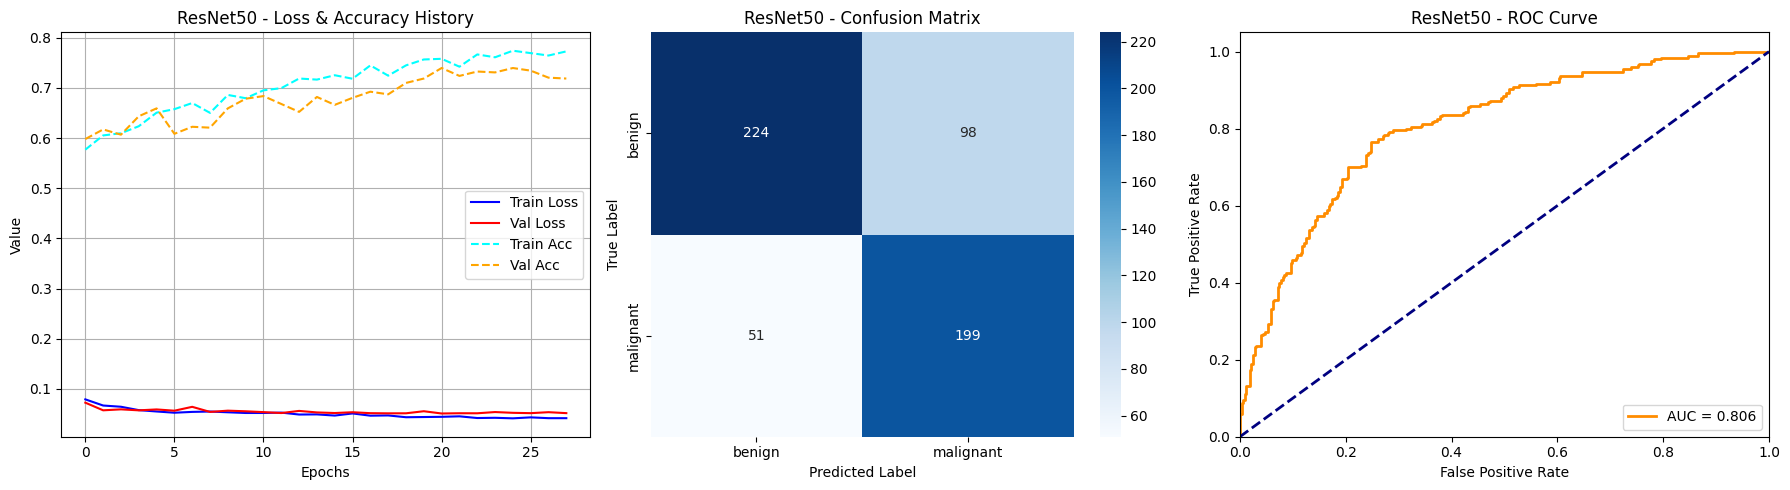


📊 Classification Report for ResNet50:

              precision    recall  f1-score   support

      benign       0.81      0.70      0.75       322
   malignant       0.67      0.80      0.73       250

    accuracy                           0.74       572
   macro avg       0.74      0.75      0.74       572
weighted avg       0.75      0.74      0.74       572



In [6]:
name='ResNet50'; model = get_model(name, len(class_names)); metrics=train_and_evaluate_model(model, name, criterion); results.append(metrics); del model; gc.collect(); torch.cuda.empty_cache()

### 5.2 Train EfficientNetB3


Training EfficientNetB3...

Epoch 1/30 | Current LR: 0.000100
---------------
Train Loss: 0.0779 | Train Acc: 58.20%
Val   Loss: 0.0616 | Val Acc:   59.44% | Val Prec: 52.42% | Val Rec: 78.00% | Val F1: 62.70%
--> Saved best model (F1: 0.6270, Threshold: 0.500)

Epoch 2/30 | Current LR: 0.000100
---------------
Train Loss: 0.0699 | Train Acc: 60.12%
Val   Loss: 0.0608 | Val Acc:   61.19% | Val Prec: 53.85% | Val Rec: 78.40% | Val F1: 63.84%
--> Saved best model (F1: 0.6384, Threshold: 0.500)

Epoch 3/30 | Current LR: 0.000099
---------------
Train Loss: 0.0658 | Train Acc: 62.22%
Val   Loss: 0.0592 | Val Acc:   61.54% | Val Prec: 54.57% | Val Rec: 71.60% | Val F1: 61.94%
--> No F1 improvement for 1 epochs.

Epoch 4/30 | Current LR: 0.000098
---------------
Train Loss: 0.0602 | Train Acc: 62.83%
Val   Loss: 0.0564 | Val Acc:   60.49% | Val Prec: 53.37% | Val Rec: 76.00% | Val F1: 62.71%
--> No F1 improvement for 2 epochs.

Epoch 5/30 | Current LR: 0.000096
---------------
Train Loss: 0

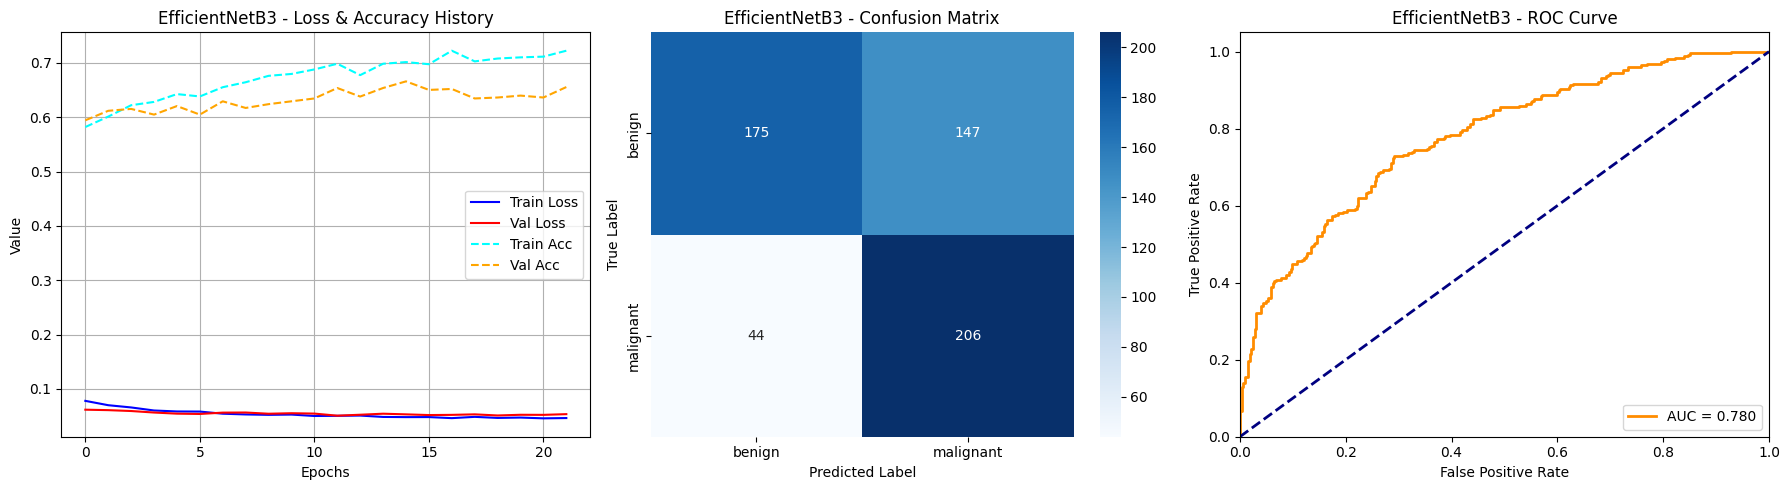


📊 Classification Report for EfficientNetB3:

              precision    recall  f1-score   support

      benign       0.80      0.54      0.65       322
   malignant       0.58      0.82      0.68       250

    accuracy                           0.67       572
   macro avg       0.69      0.68      0.67       572
weighted avg       0.70      0.67      0.66       572



In [7]:
name = 'EfficientNetB3'
model = get_model(name, len(class_names))
# Assuming 'criterion' is your FocalLoss from previous cells
metrics = train_and_evaluate_model(model, name, criterion)
results.append(metrics)
# Cleanup to prevent CUDA Out of Memory
del model
gc.collect()
torch.cuda.empty_cache()

### 5.3 Train DenseNet121


Training DenseNet121...

Epoch 1/30 | Current LR: 0.000100
---------------
Train Loss: 0.0808 | Train Acc: 59.25%
Val   Loss: 0.0613 | Val Acc:   60.14% | Val Prec: 53.44% | Val Rec: 68.40% | Val F1: 60.00%
--> Saved best model (F1: 0.6000, Threshold: 0.350)

Epoch 2/30 | Current LR: 0.000100
---------------
Train Loss: 0.0674 | Train Acc: 62.30%
Val   Loss: 0.0566 | Val Acc:   62.41% | Val Prec: 55.04% | Val Rec: 76.40% | Val F1: 63.99%
--> Saved best model (F1: 0.6399, Threshold: 0.450)

Epoch 3/30 | Current LR: 0.000099
---------------
Train Loss: 0.0663 | Train Acc: 59.86%
Val   Loss: 0.0618 | Val Acc:   61.54% | Val Prec: 53.77% | Val Rec: 85.60% | Val F1: 66.05%
--> Saved best model (F1: 0.6605, Threshold: 0.500)

Epoch 4/30 | Current LR: 0.000098
---------------
Train Loss: 0.0612 | Train Acc: 62.09%
Val   Loss: 0.0596 | Val Acc:   62.59% | Val Prec: 54.55% | Val Rec: 86.40% | Val F1: 66.87%
--> Saved best model (F1: 0.6687, Threshold: 0.500)

Epoch 5/30 | Current LR: 0.000096


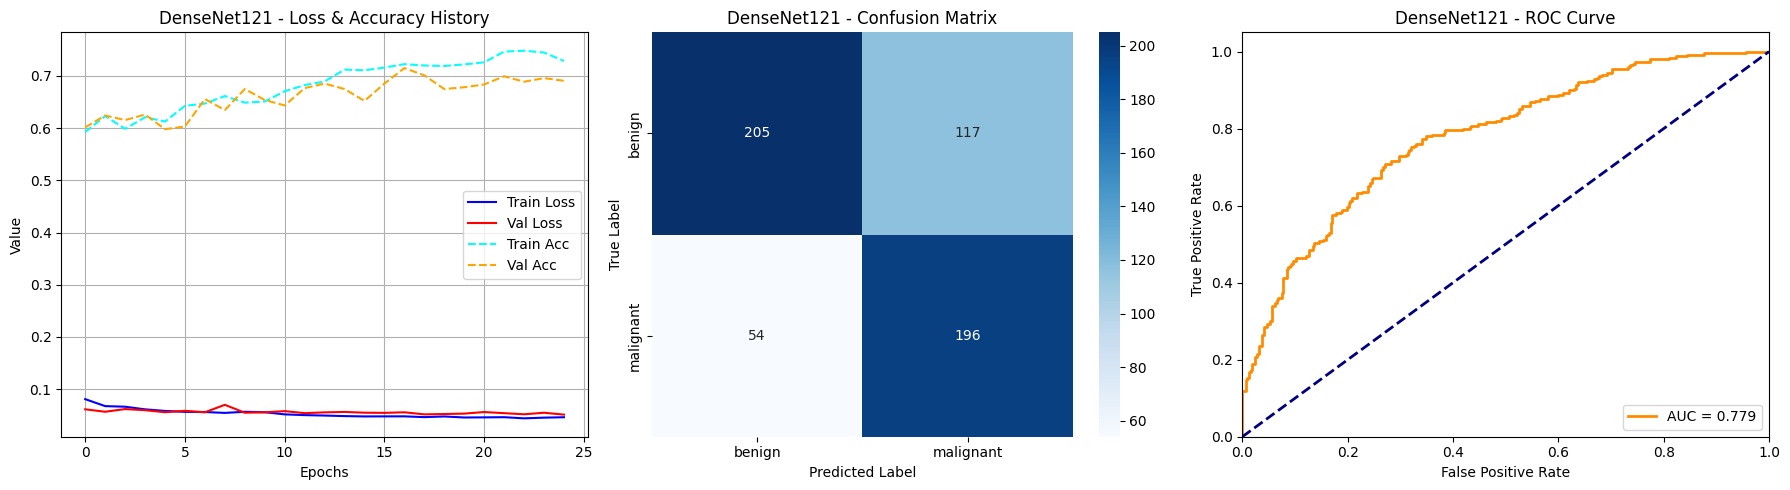


📊 Classification Report for DenseNet121:

              precision    recall  f1-score   support

      benign       0.79      0.64      0.71       322
   malignant       0.63      0.78      0.70       250

    accuracy                           0.70       572
   macro avg       0.71      0.71      0.70       572
weighted avg       0.72      0.70      0.70       572



In [8]:
name='DenseNet121'; model = get_model(name, len(class_names)); metrics=train_and_evaluate_model(model, name, criterion); results.append(metrics); del model; gc.collect(); torch.cuda.empty_cache()

### 5.4 Train MobileNetV2


Training MobileNetV2...

Epoch 1/30 | Current LR: 0.000100
---------------
Train Loss: 0.0821 | Train Acc: 56.46%
Val   Loss: 0.0621 | Val Acc:   54.55% | Val Prec: 48.83% | Val Rec: 83.20% | Val F1: 61.54%
--> Saved best model (F1: 0.6154, Threshold: 0.450)

Epoch 2/30 | Current LR: 0.000100
---------------
Train Loss: 0.0712 | Train Acc: 58.68%
Val   Loss: 0.0607 | Val Acc:   58.04% | Val Prec: 51.38% | Val Rec: 74.40% | Val F1: 60.78%
--> No F1 improvement for 1 epochs.

Epoch 3/30 | Current LR: 0.000099
---------------
Train Loss: 0.0617 | Train Acc: 62.65%
Val   Loss: 0.0603 | Val Acc:   59.62% | Val Prec: 52.82% | Val Rec: 71.20% | Val F1: 60.65%
--> No F1 improvement for 2 epochs.

Epoch 4/30 | Current LR: 0.000098
---------------
Train Loss: 0.0644 | Train Acc: 60.99%
Val   Loss: 0.0643 | Val Acc:   60.31% | Val Prec: 53.56% | Val Rec: 69.20% | Val F1: 60.38%
--> No F1 improvement for 3 epochs.

Epoch 5/30 | Current LR: 0.000096
---------------
Train Loss: 0.0600 | Train Acc: 

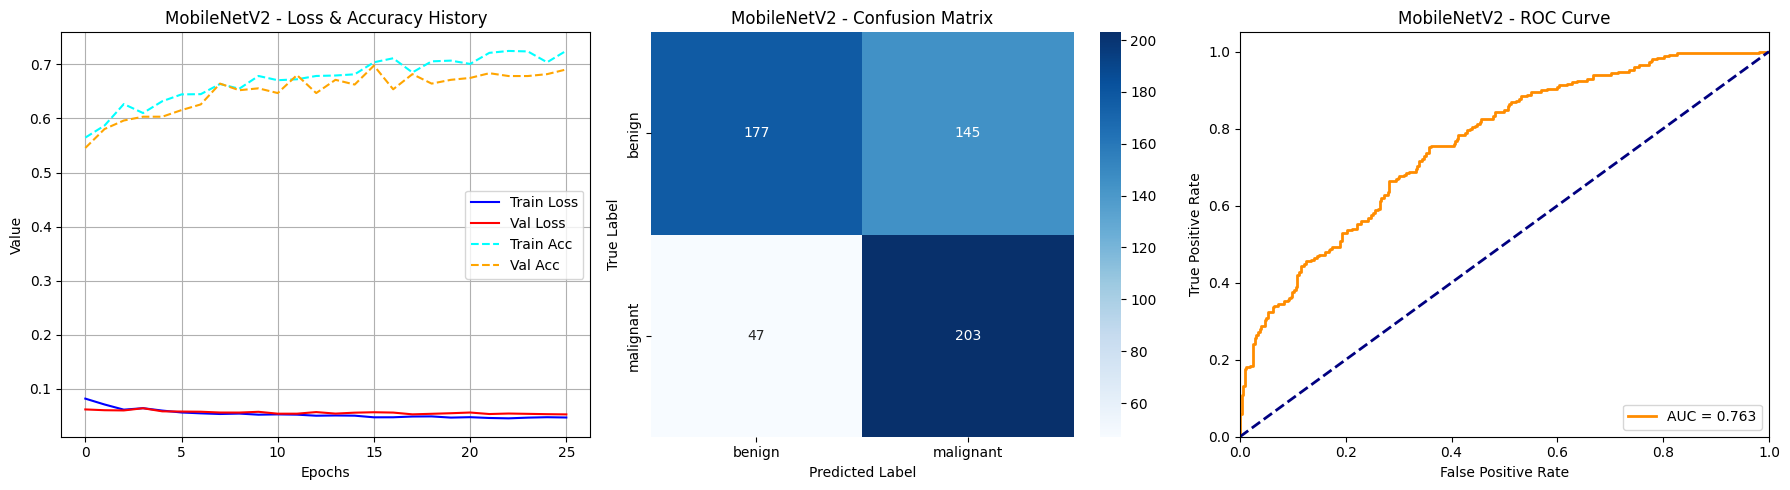


📊 Classification Report for MobileNetV2:

              precision    recall  f1-score   support

      benign       0.79      0.55      0.65       322
   malignant       0.58      0.81      0.68       250

    accuracy                           0.66       572
   macro avg       0.69      0.68      0.66       572
weighted avg       0.70      0.66      0.66       572



In [9]:
name='MobileNetV2'; model = get_model(name, len(class_names)); metrics=train_and_evaluate_model(model, name, criterion); results.append(metrics); del model; gc.collect(); torch.cuda.empty_cache()

### 5.5 Train ShuffleNetV2


Training ShuffleNetV2...

Epoch 1/30 | Current LR: 0.000100
---------------
Train Loss: 0.0756 | Train Acc: 57.55%
Val   Loss: 0.0574 | Val Acc:   55.59% | Val Prec: 49.56% | Val Rec: 89.20% | Val F1: 63.71%
--> Saved best model (F1: 0.6371, Threshold: 0.500)

Epoch 2/30 | Current LR: 0.000100
---------------
Train Loss: 0.0687 | Train Acc: 59.95%
Val   Loss: 0.0624 | Val Acc:   58.22% | Val Prec: 51.47% | Val Rec: 76.80% | Val F1: 61.64%
--> No F1 improvement for 1 epochs.

Epoch 3/30 | Current LR: 0.000099
---------------
Train Loss: 0.0644 | Train Acc: 62.78%
Val   Loss: 0.0604 | Val Acc:   60.49% | Val Prec: 53.61% | Val Rec: 71.20% | Val F1: 61.17%
--> No F1 improvement for 2 epochs.

Epoch 4/30 | Current LR: 0.000098
---------------
Train Loss: 0.0658 | Train Acc: 61.21%
Val   Loss: 0.0594 | Val Acc:   60.31% | Val Prec: 53.43% | Val Rec: 71.60% | Val F1: 61.20%
--> No F1 improvement for 3 epochs.

Epoch 5/30 | Current LR: 0.000096
---------------
Train Loss: 0.0626 | Train Acc:

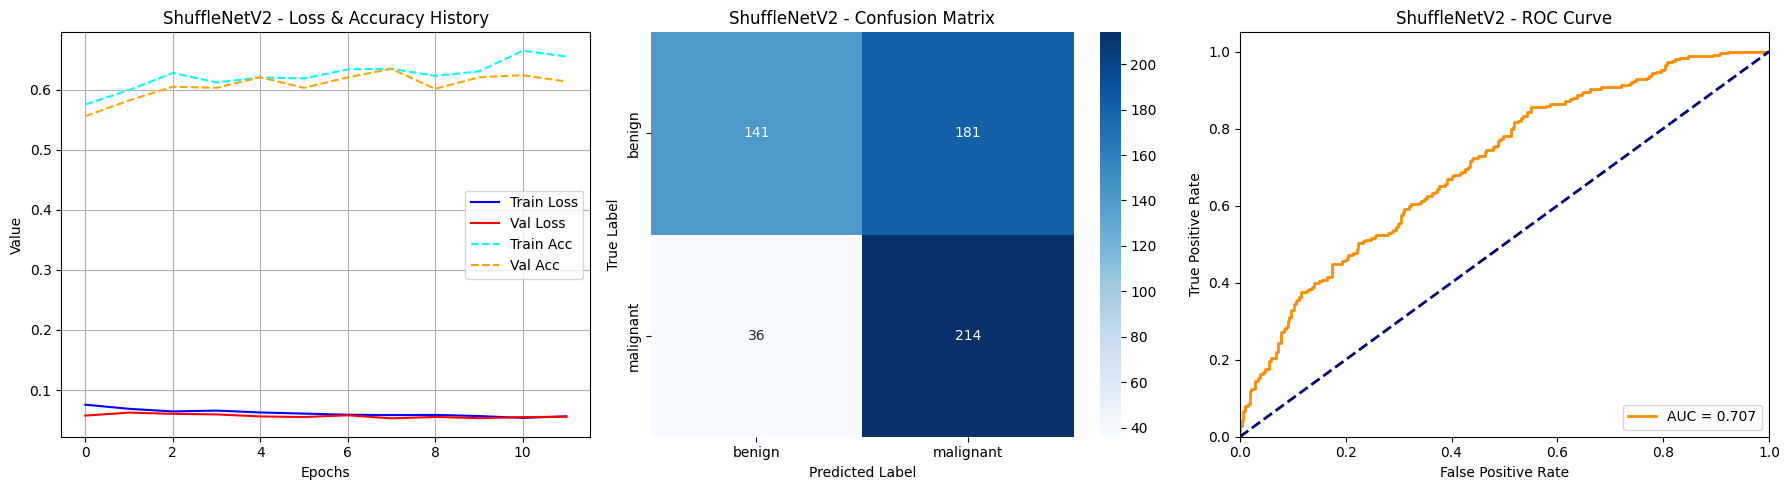


📊 Classification Report for ShuffleNetV2:

              precision    recall  f1-score   support

      benign       0.80      0.44      0.57       322
   malignant       0.54      0.86      0.66       250

    accuracy                           0.62       572
   macro avg       0.67      0.65      0.61       572
weighted avg       0.69      0.62      0.61       572



In [10]:
name = 'ShuffleNetV2'
model = get_model(name, len(class_names))
# Start the training and metrics evaluation
metrics = train_and_evaluate_model(model, name, criterion)
results.append(metrics)
# Cleanup
del model; gc.collect(); torch.cuda.empty_cache()

## 6. Overall System Output Comparisons


=== MODEL COMPARISON RESULTS ===


,Model,Accuracy,Precision,Recall,F1-Score,AUC,Optimal Threshold
0,ResNet50,73.95%,67.00%,79.60%,72.76%,80.60%,0.500
1,EfficientNetB3,66.61%,58.36%,82.40%,68.33%,77.96%,0.500
2,DenseNet121,70.10%,62.62%,78.40%,69.63%,77.92%,0.500
3,MobileNetV2,66.43%,58.33%,81.20%,67.89%,76.28%,0.500
4,ShuffleNetV2,62.06%,54.18%,85.60%,66.36%,70.69%,0.500


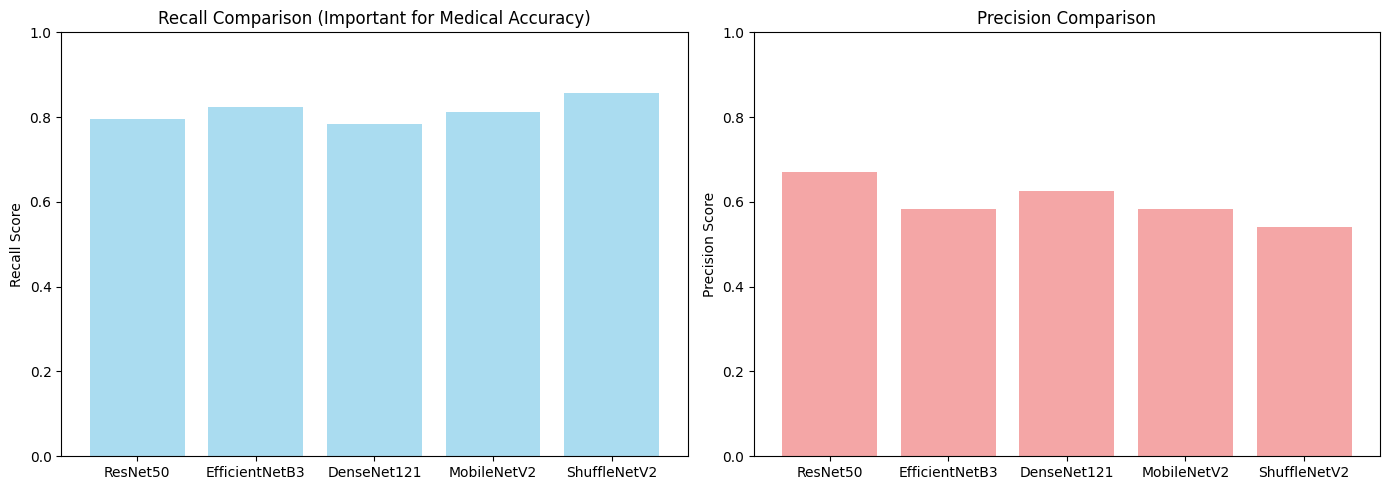

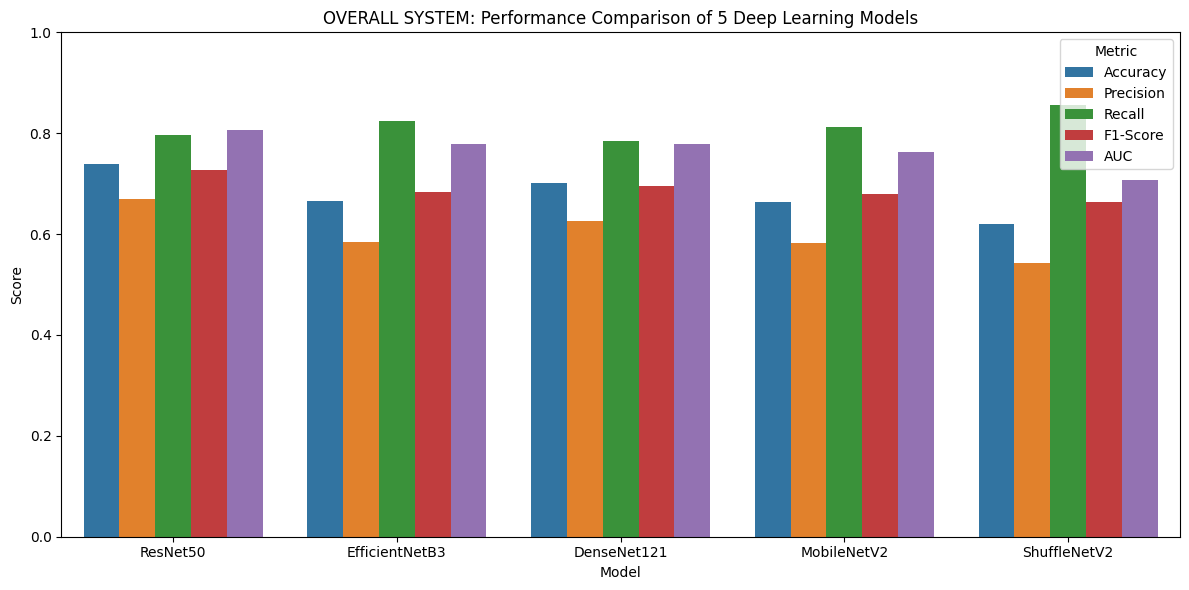

In [11]:
import os

# Generate Markdown and HTML Table comparison
# If results is empty (e.g. after kernel restart), load from saved CSV
if len(results) == 0 and os.path.exists('model_comparison_results.csv'):
    display_df = pd.read_csv('model_comparison_results.csv')
    print('Loaded results from saved CSV (results list was empty).')
else:
    display_df = pd.DataFrame(results)
    if len(display_df) > 0:
        display_df.to_csv('model_comparison_results.csv', index=False)

print('\n=== MODEL COMPARISON RESULTS ===')
display(display_df)

# Expected metric columns
metric_cols = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC']

# Only run visualizations if all required columns exist
if len(display_df) > 0 and all(c in display_df.columns for c in metric_cols):
    clean_df = display_df.copy()
    for col in metric_cols:
        clean_df[col] = clean_df[col].str.rstrip('%').astype('float') / 100.0

    # Display Precision and Recall comparison
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    recall_data = clean_df[['Model', 'Recall']].set_index('Model')
    ax1.bar(recall_data.index, recall_data['Recall'], color='skyblue', alpha=0.7)
    ax1.set_ylabel('Recall Score')
    ax1.set_title('Recall Comparison (Important for Medical Accuracy)')
    ax1.set_ylim(0, 1.0)

    precision_data = clean_df[['Model', 'Precision']].set_index('Model')
    ax2.bar(precision_data.index, precision_data['Precision'], color='lightcoral', alpha=0.7)
    ax2.set_ylabel('Precision Score')
    ax2.set_title('Precision Comparison')
    ax2.set_ylim(0, 1.0)

    plt.tight_layout()
    plt.savefig('recall_precision_comparison.png')
    plt.show()

    # Overall metrics visualization
    plt.figure(figsize=(12, 6))
    df_melted = clean_df.melt(id_vars='Model', value_vars=metric_cols, var_name='Metric', value_name='Score')
    sns.barplot(x='Model', y='Score', hue='Metric', data=df_melted)
    plt.title('OVERALL SYSTEM: Performance Comparison of 5 Deep Learning Models')
    plt.ylim(0.0, 1.0)
    plt.ylabel('Score')
    plt.tight_layout()
    plt.savefig('overall_model_comparison_chart.png')
    plt.show()
else:
    print('No results to visualize. Run the training cells first (sections 5.1-5.5).')


## 7. Ensemble Inference via Soft Voting
Averages probabilities from all 5 models to improve overall metrics.

In [49]:
def weighted_ensemble_predict(models, weights, dataloader, device):
    """Weights = per-model val F1 scores, normalized"""
    w = np.array(weights)
    w = w / w.sum()  # normalize
    
    all_model_probs = [[] for _ in models]
    all_labels = []
    
    for m in models:
        m.eval()
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            all_labels.extend(labels.numpy())
            for i, m in enumerate(models):
                outputs = m(inputs)
                probs = F.softmax(outputs, dim=1)[:, 1]
                all_model_probs[i].extend(probs.cpu().numpy())
    
    all_model_probs = np.array(all_model_probs)  # [n_models, n_samples]
    avg_probs = (all_model_probs * w[:, None]).sum(axis=0)  # weighted sum
    
    threshold = find_optimal_threshold(avg_probs, all_labels, metric='f1')
    preds = (avg_probs >= threshold).astype(int)
    return avg_probs, preds, all_labels, threshold

# Uncomment and run this after training all 5 models:
model_names_demo = ['ResNet50', 'DenseNet121', 'EfficientNetB3', 'MobileNetV2', 'ShuffleNetV2']
loaded_models = []
for name in model_names:
    m = get_model(name, len(class_names))
    checkpoint = torch.load(f'best_{name}.pth', map_location=DEVICE)
    m.load_state_dict(checkpoint)
    m = m.to(DEVICE)
    m.eval()
    loaded_models.append(m)

# Evaluate ensemble on TEST set
# Extract F1 scores automatically from the display_df tracking dataframe
val_f1_scores = []
for name in model_names:
    try:
        f1_val = display_df[display_df['Model'] == name]['F1-Score'].values[0]
        if isinstance(f1_val, str):
            f1_val = float(f1_val.strip('%')) / 100.0
        elif isinstance(f1_val, float) and f1_val > 1.0:
            f1_val = f1_val / 100.0
        val_f1_scores.append(f1_val)
    except Exception as e:
        print(f"Warning: Could not automatically find F1 score for {name}, defaulting to 0.6...")
        val_f1_scores.append(0.6)


# Evaluate ensemble on TEST set using the automated val F1 scores
avg_probs, preds, labels, best_thresh = weighted_ensemble_predict(
    loaded_models, val_f1_scores, dataloaders['val'], DEVICE
)

print(f"Ensemble Optimal Threshold: {best_thresh:.3f}")
print(f"Ensemble F1-Score: {f1_score(labels, preds)*100:.2f}%")
print(f"Ensemble Precision: {precision_score(labels, preds)*100:.2f}%")
print(f"Ensemble Recall: {recall_score(labels, preds)*100:.2f}%")
print("\nClassification Report:")
print(classification_report(labels, preds, target_names=class_names))


Ensemble Optimal Threshold: 0.500
Ensemble F1-Score: 71.03%
Ensemble Precision: 62.42%
Ensemble Recall: 82.40%

Classification Report:
              precision    recall  f1-score   support

      benign       0.82      0.61      0.70       322
   malignant       0.62      0.82      0.71       250

    accuracy                           0.71       572
   macro avg       0.72      0.72      0.71       572
weighted avg       0.73      0.71      0.71       572



## 8. Real-World Inference Demo

     REAL-WORLD INFERENCE DEMO      
Loading best weights for ResNet50...


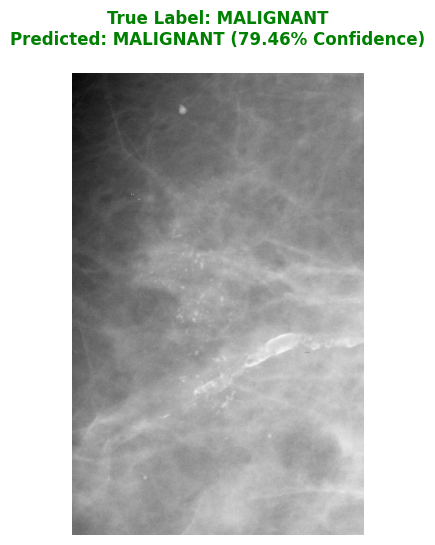

In [35]:
import random
from PIL import Image
import torchvision.transforms.functional as TF

print("     REAL-WORLD INFERENCE DEMO      ")
demo_model_name = 'ResNet50'
if os.path.exists(f"best_{demo_model_name}.pth"):
    print(f"Loading best weights for {demo_model_name}...")
    demo_model = get_model(demo_model_name, len(class_names))
    demo_model.load_state_dict(torch.load(f"best_{demo_model_name}.pth", map_location=DEVICE))
    demo_model = demo_model.to(DEVICE)
    demo_model.eval()
    
    # Load optimal threshold
    best_threshold = 0.5
    threshold_path = f"best_{demo_model_name}_threshold.pth"
    if os.path.exists(threshold_path):
        threshold_data = torch.load(threshold_path, map_location=DEVICE, weights_only=False)
        best_threshold = threshold_data['threshold']
    
    test_dir = os.path.join(DATA_DIR, 'test')
    random_class = random.choice(class_names)
    class_dir = os.path.join(test_dir, random_class)
    random_img_name = random.choice(os.listdir(class_dir))
    img_path = os.path.join(class_dir, random_img_name)
    
    raw_img = Image.open(img_path).convert('RGB')
    input_tensor = data_transforms['test'](raw_img).unsqueeze(0).to(DEVICE)
    
    with torch.no_grad():
        outputs = demo_model(input_tensor)
        probs = F.softmax(outputs, dim=1)
        prob_malignant = probs[0, 1].item()
        # Use optimal threshold instead of 0.5
        pred_class_idx = 1 if prob_malignant >= best_threshold else 0
        confidence = max(prob_malignant, 1 - prob_malignant)
        
    predicted_label = class_names[pred_class_idx]
    true_label = random_class
    
    plt.figure(figsize=(6, 6))
    plt.imshow(raw_img)
    plt.axis('off')
    
    color = 'green' if predicted_label == true_label else 'red'
    title_text = f"True Label: {true_label.upper()}\nPredicted: {predicted_label.upper()} ({confidence*100:.2f}% Confidence)\n"
    plt.title(title_text, color=color, fontsize=12, fontweight='bold')
    plt.show()
    
    del demo_model
    gc.collect()
    torch.cuda.empty_cache()
else:
    print(f"Please train the {demo_model_name} model first to run this inference demo!")

## 9. Real-World Ensemble Inference Demo

In [47]:
import random

def predict_single_image(image_path, models, device, class_names, weights=None):
    """
    Real-world ensemble inference: pass a single mammogram image
    through all trained models and combine via weighted soft voting.

    Args:
        image_path (str): Path to the mammogram image file.
        models (dict): Dict of {model_name: model} with all trained models.
        device: torch device (cpu or cuda).
        class_names (list): e.g. ['BENIGN', 'MALIGNANT']
        weights (list): Val F1 scores per model (same order as models). 
                        If None, falls back to simple average.
    Returns:
        final_pred (str), confidence (float), individual_results (dict)
    """
    transform = transforms.Compose([
        CLAHETransform(clip_limit=2.0),
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

    img = Image.open(image_path).convert('RGB')
    img_tensor = transform(img).unsqueeze(0).to(device)  # [1, C, H, W]

    all_probs = []
    individual_results = {}

    for model_name, model in models.items():
        model.eval()
        with torch.no_grad():
            outputs = model(img_tensor)
            prob = F.softmax(outputs, dim=1)[0, 1].item()  # P(malignant)
            all_probs.append(prob)
            individual_results[model_name] = {
                'prob': prob,
                'pred': class_names[1] if prob >= 0.5 else class_names[0]
            }

    # Weighted soft voting
    if weights is not None:
        w = np.array(weights)
        w = w / w.sum()  # normalize so weights sum to 1
        avg_prob = np.sum(np.array(all_probs) * w)
        voting_method = "Weighted Soft Voting"
    else:
        avg_prob = np.mean(all_probs)  # fallback to simple average
        w = np.ones(len(all_probs)) / len(all_probs)
        voting_method = "Simple Soft Voting"

    final_pred = class_names[1] if avg_prob >= 0.5 else class_names[0]
    confidence = avg_prob if final_pred == class_names[1] else (1 - avg_prob)

    # Display results
    print('=' * 60)
    print('      BREAST CANCER ENSEMBLE INFERENCE DEMO')
    print('=' * 60)
    print(f'  Voting Method : {voting_method}')
    print(f'  Image         : {os.path.basename(image_path)}')
    print(f'  Folder        : {os.path.basename(os.path.dirname(image_path))}  (ground truth label)')
    print('-' * 60)
    print(f"  {'Model':<18s}  {'Pred':<12s}  {'Prob':>6s}  {'Weight':>8s}")
    print('-' * 60)
    for (mname, res), weight in zip(individual_results.items(), w):
        marker = '  <-- MALIGNANT' if res['pred'] == class_names[1] else ''
        print(f"  {mname:<18s}  {res['pred']:<12s}  {res['prob']:>6.2%}  {weight:>8.4f}{marker}")
    print('-' * 60)
    print(f"  {'ENSEMBLE RESULT':<18s}  {final_pred:<12s}  {confidence:>6.2%}")
    print('=' * 60)

    return final_pred, confidence, individual_results


def pick_random_test_image(test_dir):
    """
    Randomly picks any image from the test directory (across all class folders).
    Prints the ground-truth label (folder name) so you can verify the prediction.
    """
    all_images = []
    for class_folder in os.listdir(test_dir):
        folder_path = os.path.join(test_dir, class_folder)
        if os.path.isdir(folder_path):
            for fname in os.listdir(folder_path):
                if fname.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff')):
                    all_images.append(os.path.join(folder_path, fname))
    if not all_images:
        raise FileNotFoundError(f'No images found in {test_dir}')
    return random.choice(all_images)


# ---- Step 1: Load all 5 trained models ----
model_names_demo = ['ResNet50', 'DenseNet121', 'EfficientNetB3', 'MobileNetV2', 'ShuffleNetV2']
loaded_models_demo = {}

for name in model_names_demo:
    pth_path = f'best_{name}.pth'
    if os.path.exists(pth_path):
        m = get_model(name, len(class_names))
        m.load_state_dict(torch.load(pth_path, map_location=DEVICE))
        m = m.to(DEVICE)
        loaded_models_demo[name] = m
        print(f'Loaded {name}')
    else:
        print(f'[SKIP] {name} not trained yet.')


# ---- Step 2: Extract real val F1 weights from results ----
val_f1_weights = [float(r['F1-Score'].strip('%')) / 100 for r in results]


# ---- Step 3: Pick a RANDOM test image and run ensemble inference ----
if loaded_models_demo:
    TEST_DIR = os.path.join(DATA_DIR, 'test')
    random_image_path = pick_random_test_image(TEST_DIR)
    print(f'\nRandomly selected: {random_image_path}\n')

    final_pred, confidence, individual_results = predict_single_image(
        random_image_path, loaded_models_demo, DEVICE, class_names,
        weights=val_f1_weights  # pass real val F1 weights
    )
else:
    print('No models loaded. Train at least one model before running inference.')

Loaded ResNet50
Loaded DenseNet121
Loaded EfficientNetB3
Loaded MobileNetV2
Loaded ShuffleNetV2

Randomly selected: dataset\test\malignant\Calc-Test_P_01390_RIGHT_MLO_2.png

      BREAST CANCER ENSEMBLE INFERENCE DEMO
  Voting Method : Weighted Soft Voting
  Image         : Calc-Test_P_01390_RIGHT_MLO_2.png
  Folder        : malignant  (ground truth label)
------------------------------------------------------------
  Model               Pred            Prob    Weight
------------------------------------------------------------
  ResNet50            malignant     50.37%    0.2109  <-- MALIGNANT
  DenseNet121         malignant     58.12%    0.1981  <-- MALIGNANT
  EfficientNetB3      benign        49.80%    0.2018
  MobileNetV2         benign        48.40%    0.1968
  ShuffleNetV2        malignant     52.16%    0.1924  <-- MALIGNANT
------------------------------------------------------------
  ENSEMBLE RESULT     malignant     51.75%
